# **Threshold-Based Segmentation**

**Simple Thresholding**

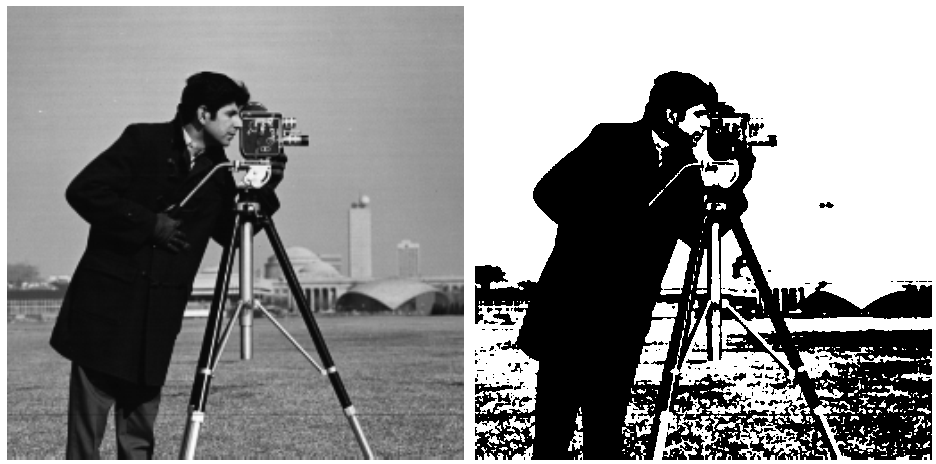

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load image
img = cv2.imread('thr.png', cv2.IMREAD_GRAYSCALE)

# Global threshold
_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Display
cv2_imshow(np.hstack([img, thresh]))

**Adaptive Thresholding**

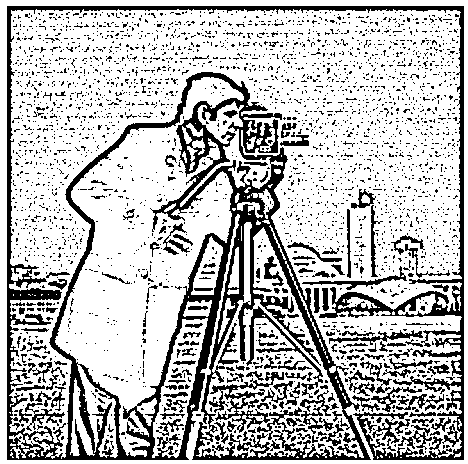

In [2]:
# Adaptive threshold (better for uneven lighting)
adapt_thresh = cv2.adaptiveThreshold(img, 255,
                                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)
cv2_imshow(adapt_thresh)

# **Point Detection**

**Isolated Point Detection with Morphology**

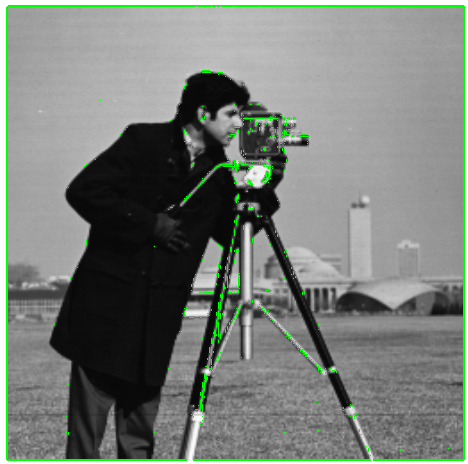

In [5]:
# Define point detection kernel
kernel = np.array([
    [1, 1, 1],
    [1,-8, 1],
    [1, 1, 1]
], dtype=np.float32)

# Convolve with image
point_response = cv2.filter2D(img.astype(np.float32), -1, kernel)
isolated_points = np.abs(point_response) > 200  # Threshold

# Display
marked = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
marked[isolated_points] = [0,255,0]  # Green marks
cv2_imshow(marked)

**Corner Detection (Harris) for Feature Points**

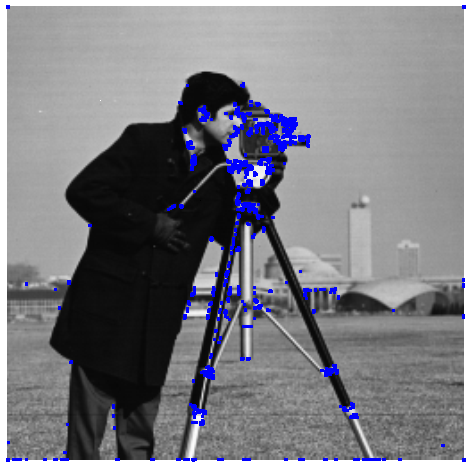

In [6]:
# Harris corner detection
corners = cv2.cornerHarris(img, blockSize=2, ksize=3, k=0.04)
corners = cv2.dilate(corners, None)  # Enhance corner points

# Threshold and mark
threshold = 0.01 * corners.max()
result = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
result[corners > threshold] = [255,0,0]  # Blue marks

cv2_imshow(result)

**Blob Detection (SimpleBlobDetector)**

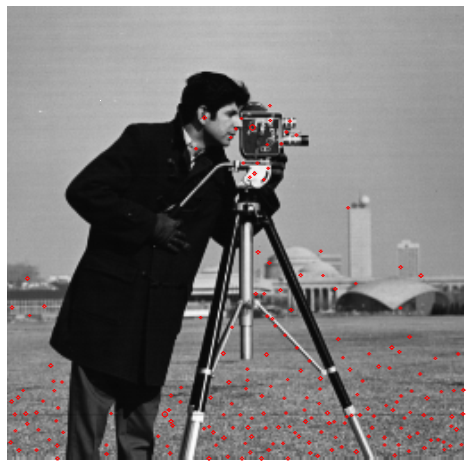

In [7]:
# Set up blob detector
params = cv2.SimpleBlobDetector_Params()
params.filterByArea = True
params.minArea = 1       # Detect single pixels
params.maxArea = 10      # Small blobs only
params.filterByCircularity = False
params.filterByConvexity = False

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(img)

# Draw detected points
result = cv2.drawKeypoints(img, keypoints, np.array([]), (0,0,255),
                          cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
cv2_imshow(result)

# **Line Detection**

**Canny Edge + Hough Transform**

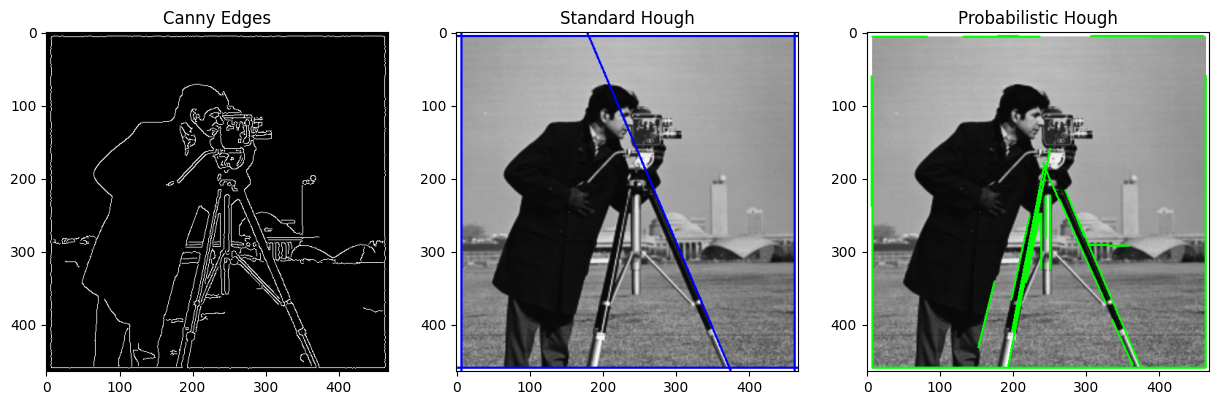

In [9]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load and preprocess image
img = cv2.imread('thr.png', 0)
blurred = cv2.GaussianBlur(img, (5,5), 0)

# Canny edge detection
edges = cv2.Canny(blurred, 50, 150)

# Standard Hough Line Transform
lines = cv2.HoughLines(edges, 1, np.pi/180, threshold=150)

# Draw lines
hough_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
if lines is not None:
    for rho, theta in lines[:,0]:
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a*rho, b*rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*a))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*a))
        cv2.line(hough_img, pt1, pt2, (0,0,255), 2)

# Probabilistic Hough Transform
p_lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80,
                         minLineLength=50, maxLineGap=10)
prob_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
if p_lines is not None:
    for line in p_lines:
        x1,y1,x2,y2 = line[0]
        cv2.line(prob_img, (x1,y1), (x2,y2), (0,255,0), 2)

# Display results
plt.figure(figsize=(15,5))
plt.subplot(131), plt.imshow(edges, cmap='gray'), plt.title('Canny Edges')
plt.subplot(132), plt.imshow(hough_img), plt.title('Standard Hough')
plt.subplot(133), plt.imshow(prob_img), plt.title('Probabilistic Hough')
plt.show()

# **Edge Detection**

Original Image:


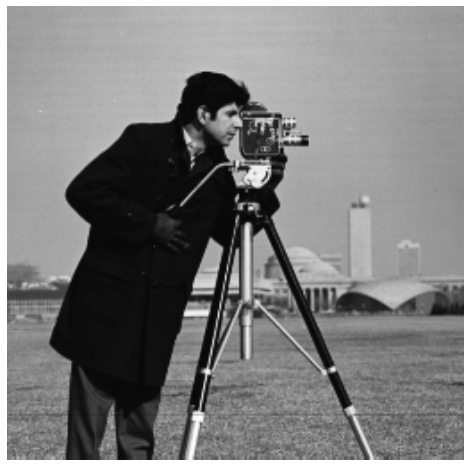


Sobel X (Vertical Edges):


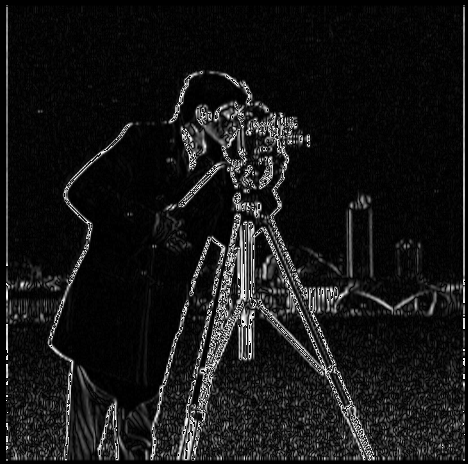

In [12]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read the image in grayscale
image = cv2.imread('thr.png', cv2.IMREAD_GRAYSCALE)

# Apply Sobel X (detects vertical edges)
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)

# Convert to absolute values and scale to 8-bit (0-255)
sobel_x = np.uint8(np.abs(sobel_x))

# Display results in Colab
print("Original Image:")
cv2_imshow(image)

print("\nSobel X (Vertical Edges):")
cv2_imshow(sobel_x)

# **Edge Detection Using First-Order Derivative (Sobel & Prewitt Operators)**

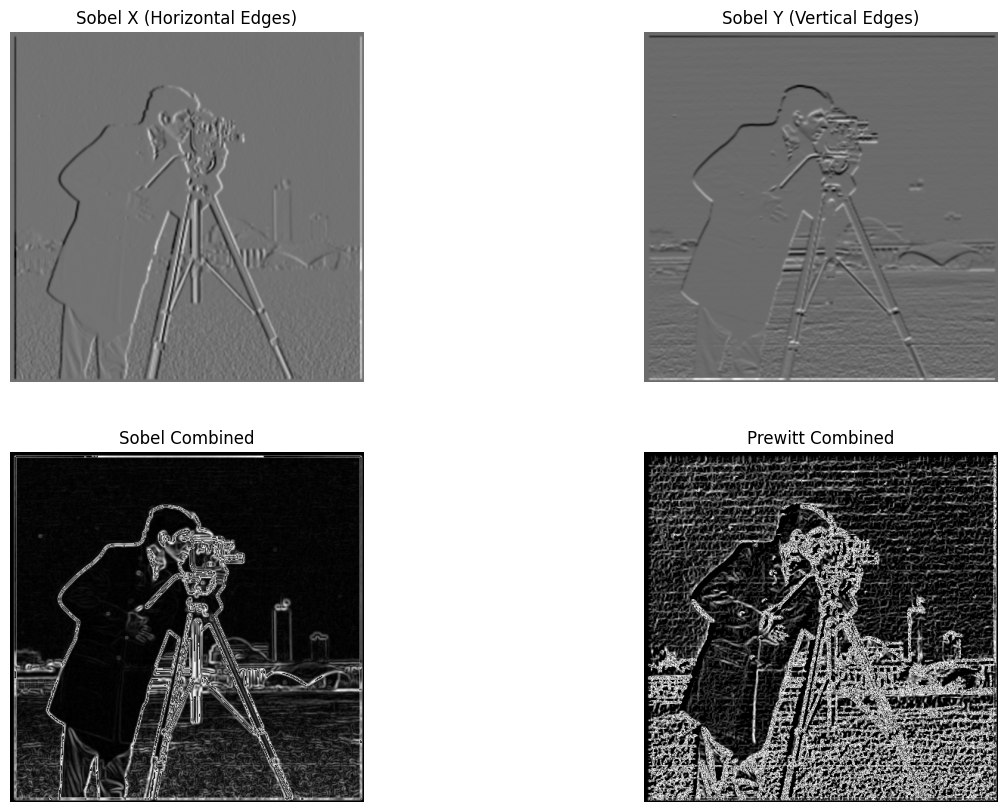

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
image = cv2.imread("thr.png", cv2.IMREAD_GRAYSCALE)

# Apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(image, (3, 3), 0)

### **1. Sobel Edge Detection**
sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal edges
sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)  # Vertical edges
sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)  # Magnitude
sobel_combined = np.uint8(sobel_combined)

### **2. Prewitt Edge Detection (Manual Implementation)**
kernel_prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])  # Horizontal
kernel_prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])  # Vertical

prewitt_x = cv2.filter2D(blurred, -1, kernel_prewitt_x)
prewitt_y = cv2.filter2D(blurred, -1, kernel_prewitt_y)
prewitt_combined = np.sqrt(prewitt_x**2 + prewitt_y**2)
prewitt_combined = np.uint8(prewitt_combined)

### **Display Results**
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1), plt.imshow(sobel_x, cmap='gray')
plt.title("Sobel X (Horizontal Edges)"), plt.axis('off')

plt.subplot(2, 2, 2), plt.imshow(sobel_y, cmap='gray')
plt.title("Sobel Y (Vertical Edges)"), plt.axis('off')

plt.subplot(2, 2, 3), plt.imshow(sobel_combined, cmap='gray')
plt.title("Sobel Combined"), plt.axis('off')

plt.subplot(2, 2, 4), plt.imshow(prewitt_combined, cmap='gray')
plt.title("Prewitt Combined"), plt.axis('off')

plt.show()

# **Marr-Hildreth Edge Detector (Laplacian of Gaussian - LoG)**

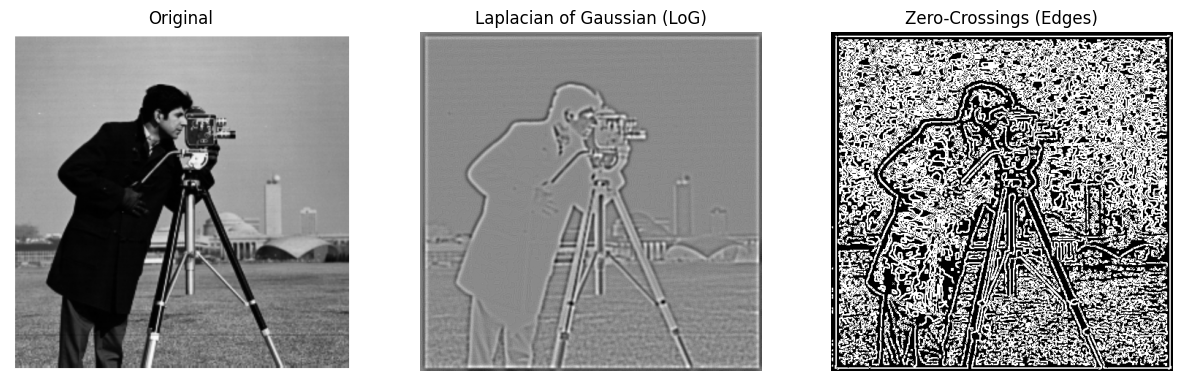

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
image = cv2.imread("thr.png", cv2.IMREAD_GRAYSCALE)

### **Step 1: Gaussian Smoothing (σ controls blur)**
sigma = 2.0  # Adjust for more/less smoothing
gaussian = cv2.GaussianBlur(image, (0, 0), sigma)

### **Step 2: Laplacian Operator (2nd derivative)**
laplacian = cv2.Laplacian(gaussian, cv2.CV_64F, ksize=3)

### **Step 3: Zero-Crossing Detection (edges)**
# Thresholding to find zero-crossings
zero_crossings = np.zeros_like(laplacian)
h, w = laplacian.shape
for i in range(1, h-1):
    for j in range(1, w-1):
        neighbors = [
            laplacian[i-1, j], laplacian[i+1, j],
            laplacian[i, j-1], laplacian[i, j+1],
            laplacian[i-1, j-1], laplacian[i+1, j+1],
            laplacian[i-1, j+1], laplacian[i+1, j-1]
        ]
        if (laplacian[i, j] > 0 and min(neighbors) < 0) or (laplacian[i, j] < 0 and max(neighbors) > 0):
            zero_crossings[i, j] = 255  # Edge pixel

### **Display Results**
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1), plt.imshow(image, cmap='gray')
plt.title("Original"), plt.axis('off')

plt.subplot(1, 3, 2), plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian of Gaussian (LoG)"), plt.axis('off')

plt.subplot(1, 3, 3), plt.imshow(zero_crossings, cmap='gray')
plt.title("Zero-Crossings (Edges)"), plt.axis('off')

plt.show()